# Library

In [1]:
# load libraries
from pathlib import Path
from collections import namedtuple
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
methods = ['velocyto',
           'scvelo_dyn',
           'scvelo_stc',
           'veloae',
           'dynamo_m1',
           'unitvelo_ind',
           'unitvelo_uni',
           'velovae_std',
           'velovae_fullvb',
           'deepvelo',
           'celldancer',
           'pyrovelocity_m1',
           'pyrovelocity_m2',
           'kvelo',
           'velovi',
           'sdevelo',
           'cell2fate',
           'svelvetvae', 
           'latentvelo_std',
           'latentvelo_atac',
           'tivelo_std', 
           'tivelo_simple', 
           'sctour_mse',
           'sctour_nb', 
           'sctour_zinb', 
           'graphvelo_std',
           'graphvelo_atac',
           'multivelo']

newmethods = {
    'unitvelo_ind': 'UniTVelo (ind)',
    'velovi': 'VeloVI',
    'cell2fate': 'cell2fate',
    'latentvelo_atac': 'LatentVelo (ATAC)',
    'latentvelo_std': 'LatentVelo (std)',
    'pyrovelocity_m1': 'Pyro-velocity (m1)',
    'pyrovelocity_m2': 'Pyro-velocity (m2)',
    'sctour_mse': 'scTour (MSE)',
    'sctour_nb': 'scTour (NB)',
    'sctour_zinb': 'scTour (ZINB)',
    'scvelo_dyn': 'scVelo (dyn)',
    'unitvelo_uni': 'UniTVelo (uni)',
    'deepvelo': 'DeepVelo',
    'svelvetvae': 'SvelvetVAE',
    'tivelo_std': 'TIVelo (std)',
    'tivelo_simple': 'TIVelo (simple)',
    'velocyto': 'Velocyto',
    'veloae': 'VeloAE',
    'velovae_std': 'VeloVAE',
    'velovae_fullvb': 'VeloVAE (Full VB)',
    'kvelo': '  -velo',
    'celldancer': 'cellDancer',
    'dynamo': 'Dynamo (m1)',
    'graphvelo_std': 'GraphVelo (std)',
    'graphvelo_atac': 'GraphVelo (ATAC)',
    'scvelo_stc': 'scVelo (stc)',
    'sdevelo': 'SDEvelo',
    'multivelo': 'MultiVelo'
}


dataset_names = ['data22','data23','data24']

dataset_ids = ['Data 18','Data 19','Data 20']

# CBDir

In [3]:
metric = 'cbdir'

all_dfs = []
for dataset_name in dataset_names:
    df = pd.read_csv(f'{dataset_name}/{metric}_df.csv')
    all_dfs.append(df)

method_avg_df = pd.DataFrame()

for i, df in enumerate(all_dfs):

    fold_columns = [col for col in df.columns if col != 'Method']
    
    method_avg = df.groupby('Method')[fold_columns].mean().mean(axis=1).reset_index()
    method_avg.columns = ['Method', f'{dataset_names[i]}_avg']
    
    if method_avg_df.empty:
        method_avg_df = method_avg
    else:
        method_avg_df = method_avg_df.merge(method_avg, on='Method', how='outer')

method_avg_df['overall_avg'] = method_avg_df.iloc[:, 1:].mean(axis=1)
method_avg_df = method_avg_df.sort_values('overall_avg', ascending=False).reset_index(drop=True)
method_avg_df['rank'] = range(1, len(method_avg_df) + 1)

In [4]:
method_avg_df

,Method,data22_avg,data23_avg,data24_avg,overall_avg,rank
0,unitvelo_ind,0.276504,0.424822,0.639717,0.447014,1
1,graphvelo_atac,0.199736,0.373384,0.484839,0.352653,2
2,sctour_zinb,-0.028607,0.306362,0.690390,0.322715,3
3,sctour_nb,-0.021597,0.359293,0.607151,0.314949,4
4,pyrovelocity_m2,-0.049455,0.291548,0.695208,0.312434,5
5,deepvelo,0.049690,0.433883,0.447104,0.310226,6
6,unitvelo_uni,-0.015431,0.192536,0.717311,0.298139,7
7,graphvelo_std,0.133209,0.302810,0.361558,0.265859,8
8,scvelo_dyn,-0.042868,0.286278,0.510176,0.251195,9
9,tivelo_std,0.289243,0.406721,0.055001,0.250322,10


/tmp/ipykernel_141182/1873793384.py:48: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


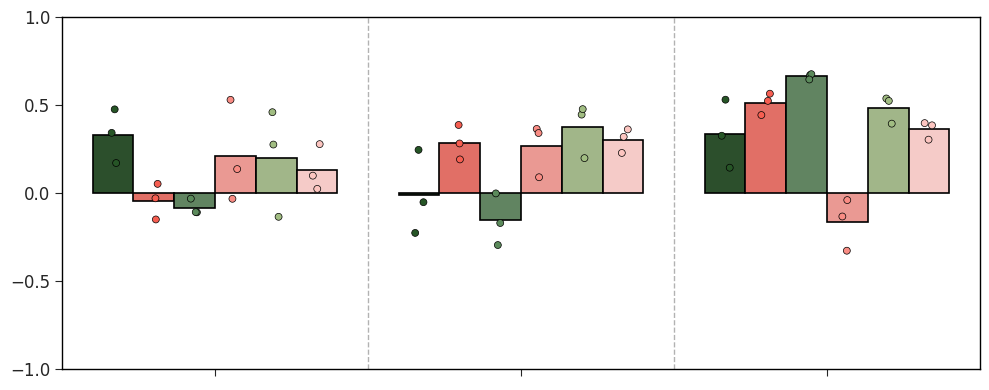

In [5]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
sns.set_style("white")

methods_to_plot = ["multivelo","scvelo_dyn","latentvelo_atac","latentvelo_std","graphvelo_atac","graphvelo_std"]

new_methods = {
    'multivelo': 'MultiVelo',
    'scvelo_dyn': 'scVelo (dyn)',
    'latentvelo_atac': 'LatentVelo (ATAC)',
    'latentvelo_std': 'LatentVelo (std) ',
    'graphvelo_atac': 'GraphVelo (ATAC) ',
    'graphvelo_std': 'GraphVelo (std) '
}

method_color = {
    'scvelo_dyn':  "#F65E51",
    'latentvelo_std': "#F98C84",
    'graphvelo_std': "#FCC5C0",
    'multivelo':  '#265526',
    'latentvelo_atac': "#5B8A5B",
    'graphvelo_atac': "#A1BD82"
}

combined = []
for idx, df in enumerate(all_dfs):
    tmp = df.melt(id_vars='Method', var_name='Fold', value_name='Metric').copy()
    tmp['Dataset'] = f"Dataset {idx+1}"
    combined.append(tmp)
combined_df = pd.concat(combined, ignore_index=True)

combined_df = combined_df[combined_df['Method'].isin(methods_to_plot)].copy()
combined_df['Method'] = pd.Categorical(combined_df['Method'], categories=methods_to_plot, ordered=True)
combined_df['Dataset'] = pd.Categorical(
    combined_df['Dataset'],
    categories=[f"Dataset {i+1}" for i in range(len(all_dfs))],
    ordered=True
)


fig, ax = plt.subplots(figsize=(10,4))


sns.barplot(
    x='Dataset', y='Metric', hue='Method', data=combined_df,
    hue_order=methods_to_plot, palette=method_color,
    ci=None, dodge=True, edgecolor='black', linewidth=1.2, ax=ax
)


sns.stripplot(
    x='Dataset', y='Metric', hue='Method', data=combined_df,
    hue_order=methods_to_plot, dodge=True, palette=method_color,
    marker='o', size=5, edgecolor='black', linewidth=0.5, alpha=1.0, ax=ax
)

ax.legend().remove()
ax.xaxis.set_tick_params(which='both', bottom=True)
ax.yaxis.set_tick_params(which='both', left=True)

num_datasets = len(all_dfs)
for i in range(num_datasets - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=0)

handles = [Patch(facecolor=method_color[m], edgecolor='black', label=new_methods[m]) for m in methods_to_plot]
legend = ax.legend(handles=handles, title="", loc='upper center', bbox_to_anchor=(0.5, -0.15),
                   ncol=4, frameon=True, fontsize=9)
ax.add_artist(legend)

ax.set_xlabel("")
ax.set_ylabel("", fontsize=12)
ax.set_xticklabels([])

ax.set_ylim(-1, 1)
ax.set_yticks([-1.0, -0.5, 0.0, 0.5, 1.0])
for label in ax.get_yticklabels():
    label.set_fontsize(12)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.0)
ax.tick_params(axis='both', length=5) 
# ax.grid(True, linestyle='--', axis='y', color='lightgray', alpha=0.7, zorder=0)

plt.tight_layout(rect=[0,0,1,1])
plt.savefig(f"ATAC_subset_{metric}.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()


# icvcoh

In [6]:
metric = 'icvcoh'

all_dfs = []
for dataset_name in dataset_names:
    df = pd.read_csv(f'{dataset_name}/{metric}_df.csv')
    all_dfs.append(df)

method_avg_df = pd.DataFrame()

for i, df in enumerate(all_dfs):

    fold_columns = [col for col in df.columns if col != 'Method']
    
    method_avg = df.groupby('Method')[fold_columns].mean().mean(axis=1).reset_index()
    method_avg.columns = ['Method', f'{dataset_names[i]}_avg']
    
    if method_avg_df.empty:
        method_avg_df = method_avg
    else:
        method_avg_df = method_avg_df.merge(method_avg, on='Method', how='outer')

method_avg_df['overall_avg'] = method_avg_df.iloc[:, 1:].mean(axis=1)
method_avg_df = method_avg_df.sort_values('overall_avg', ascending=False).reset_index(drop=True)
method_avg_df['rank'] = range(1, len(method_avg_df) + 1)

In [7]:
method_avg_df

,Method,data22_avg,data23_avg,data24_avg,overall_avg,rank
0,unitvelo_uni,0.917850,0.854096,0.941895,0.904613,1
1,latentvelo_std,0.862961,0.868725,0.918931,0.883539,2
2,sctour_zinb,0.838977,0.812752,0.876682,0.842803,3
3,sctour_nb,0.850983,0.842357,0.825672,0.839671,4
4,pyrovelocity_m2,0.829835,0.831878,0.835501,0.832405,5
5,sctour_mse,0.853087,0.777160,0.857040,0.829096,6
6,veloae,0.822173,0.837222,0.820788,0.826728,7
7,tivelo_std,0.799431,0.831271,0.753105,0.794602,8
8,pyrovelocity_m1,0.807125,0.788847,0.760840,0.785604,9
9,unitvelo_ind,0.798895,0.676589,0.827911,0.767798,10


/tmp/ipykernel_141182/2584378103.py:46: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(


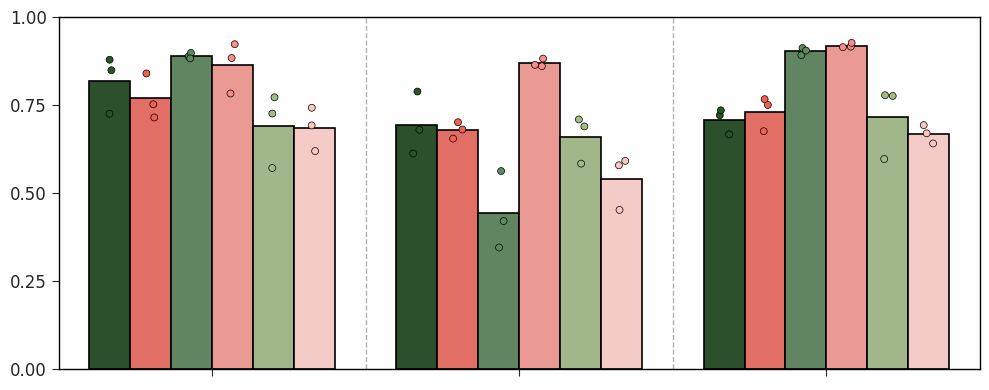

In [8]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
from matplotlib.patches import Patch
import matplotlib
matplotlib.rcParams['font.family'] = 'Arial'
sns.set_style("white")

methods_to_plot = ["multivelo","scvelo_dyn","latentvelo_atac","latentvelo_std","graphvelo_atac","graphvelo_std"]

new_methods = {
    'multivelo': 'MultiVelo',
    'scvelo_dyn': 'scVelo (dyn)',
    'latentvelo_atac': 'LatentVelo (ATAC)',
    'latentvelo_std': 'LatentVelo (std) ',
    'graphvelo_atac': 'GraphVelo (ATAC) ',
    'graphvelo_std': 'GraphVelo (std) '
}

method_color = {
    'scvelo_dyn':  "#F65E51",
    'graphvelo_std': "#FCC5C0",
    'latentvelo_std': "#F98C84",
    'multivelo':  '#265526',
    'latentvelo_atac': "#5B8A5B",
    'graphvelo_atac': "#A1BD82"
}

combined = []
for idx, df in enumerate(all_dfs):
    tmp = df.melt(id_vars='Method', var_name='Fold', value_name='Metric').copy()
    tmp['Dataset'] = f"Dataset {idx+1}"
    combined.append(tmp)
combined_df = pd.concat(combined, ignore_index=True)

combined_df = combined_df[combined_df['Method'].isin(methods_to_plot)].copy()
combined_df['Method'] = pd.Categorical(combined_df['Method'], categories=methods_to_plot, ordered=True)
combined_df['Dataset'] = pd.Categorical(
    combined_df['Dataset'],
    categories=[f"Dataset {i+1}" for i in range(len(all_dfs))],
    ordered=True
)

fig, ax = plt.subplots(figsize=(10,4))

sns.barplot(
    x='Dataset', y='Metric', hue='Method', data=combined_df,
    hue_order=methods_to_plot, palette=method_color,
    ci=None, dodge=True, edgecolor='black', linewidth=1.2, ax=ax
)

sns.stripplot(
    x='Dataset', y='Metric', hue='Method', data=combined_df,
    hue_order=methods_to_plot, dodge=True, palette=method_color,
    marker='o', size=5, edgecolor='black', linewidth=0.5, alpha=1.0, ax=ax
)


ax.legend().remove()
ax.xaxis.set_tick_params(which='both', bottom=True)
ax.yaxis.set_tick_params(which='both', left=True)
num_datasets = len(all_dfs)
for i in range(num_datasets - 1):
    ax.axvline(i + 0.5, color='gray', linestyle='--', linewidth=1, alpha=0.6, zorder=0)


handles = [Patch(facecolor=method_color[m], edgecolor='black', label=new_methods[m]) for m in methods_to_plot]
legend = ax.legend(handles=handles, title="", loc='upper center', bbox_to_anchor=(0.5, -0.15),
                   ncol=4, frameon=True, fontsize=9)
ax.add_artist(legend)

ax.set_xlabel("")
ax.set_ylabel("", fontsize=12, fontweight='bold')
ax.set_xticklabels([])

ax.set_ylim(0, 1)
ax.set_yticks([0.00, 0.25, 0.50, 0.75, 1.00])
for label in ax.get_yticklabels():
    label.set_fontsize(12)

for spine in ax.spines.values():
    spine.set_color('black')
    spine.set_linewidth(1.0)

# ax.grid(True, linestyle='--', axis='y', color='lightgray', alpha=0.7, zorder=0)
ax.tick_params(axis='both', length=5) 
plt.tight_layout(rect=[0,0,1,1])
plt.savefig(f"ATAC_subset_{metric}.svg", format="svg", bbox_inches="tight", dpi=300)
plt.show()